In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## Chapter 02b — Surfaces, Contours & Vector Fields

Many objects in machine learning are functions of **two** variables, like a
loss surface $L(w_1, w_2)$. This notebook shows the standard ways to picture a
function $f(x, y)$ and a vector field, all built on one key idea: the **grid**.

___
### 1. The grid: `np.meshgrid`

To evaluate $f(x, y)$ over a rectangle we need every combination of an $x$ and
a $y$. `np.meshgrid` takes a 1D list of $x$ values and a 1D list of $y$ values
and returns two 2D arrays `X` and `Y` such that `(X[i,j], Y[i,j])` is one grid
point. Then a vectorised formula gives `Z = f(X, Y)` for the whole grid at once.

In [2]:
# A small grid so we can SEE the arrays.
xs = np.linspace(0, 2, 3)   # [0, 1, 2]
ys = np.linspace(0, 1, 2)   # [0, 1]
X, Y = np.meshgrid(xs, ys)

print("X =\n", X)   # x-coordinate at each grid point
print("Y =\n", Y)   # y-coordinate at each grid point
print("X + Y =\n", X + Y) 

X =
 [[0. 1. 2.]
 [0. 1. 2.]]
Y =
 [[0. 0. 0.]
 [1. 1. 1.]]
X + Y =
 [[0. 1. 2.]
 [1. 2. 3.]]


___
So the grid contains:

`(0,0), (1,0), (2,0), (0,1), (1,1), (2,1)`

**Purpose:** create all `(x, y)` points needed to evaluate `f(x, y)` across a region.

____
### 2. A function of two variables

Let
$$f(x, y) = \exp\!\big(-(x^2 + y^2)\big),$$
a smooth "bump" centered at the origin. We build a fine grid and evaluate it.

In [5]:
xs = np.linspace(-2, 2, 200)
ys = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(xs, ys)

Z = np.exp(-(X ** 2 + Y ** 2))   # f(x, y) on the whole grid at once
print("Z has shape", Z.shape)   # one value per grid point

Z has shape (200, 200)


____
### 3. Contour lines: `plt.contour`

A **contour line** connects points where $f$ has the same value — exactly like
height lines on a topographic map. Closely-spaced contours mean a steep region.

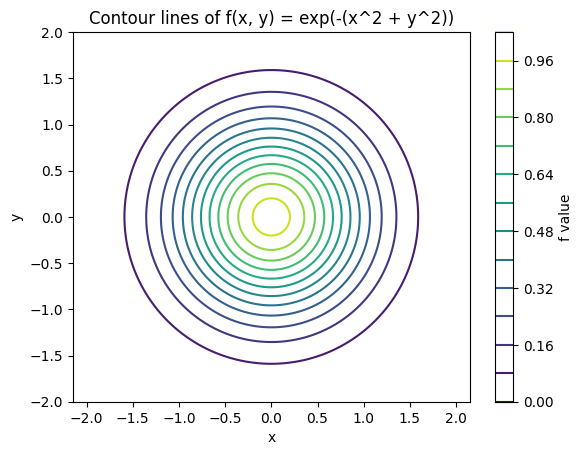

In [6]:
plt.contour(X, Y, Z, levels=12)   # 12 evenly spaced level curves
plt.title("Contour lines of f(x, y) = exp(-(x^2 + y^2))")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")        # equal scaling so circles look like circles
plt.colorbar(label="f value")
plt.show()

* **Each line:** every point along each circle has the same `f` value (all pts on yellow circle has `f` = 0.96)
* **Lines close together:** `f` changes rapidly → **steep**.
* **Lines far apart:** `f` changes slowly → **gentle**.


____
### 4. Filled contours: `plt.contourf`

`contourf` (the **f** is for *filled*) shades the bands between contours, which
reads more like a heat map. A colorbar decodes color into value.

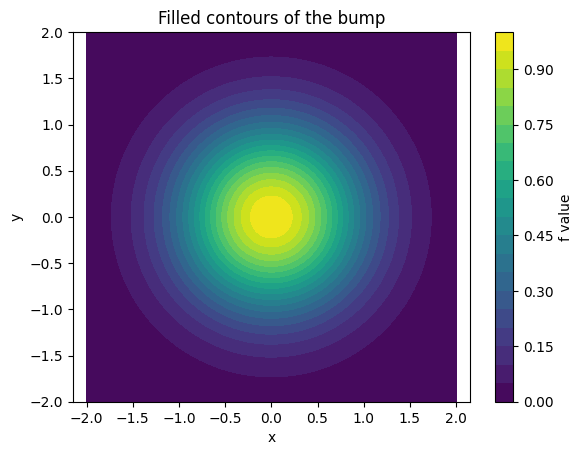

In [9]:
plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.title("Filled contours of the bump")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.colorbar(label="f value")
plt.show()